In [1]:
import pandas as pd
import numpy as np 
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv('spotify.csv')

In [3]:
df = df.drop_duplicates(subset=['uri']).reset_index(drop=True)

In [4]:
features = ['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'time_signature','chorus_hit', 'sections']

In [5]:
X= df[features]

In [6]:
print(f"Data Cleaned! Ready to process {X.shape[0]} unique songs with {X.shape[1]} features.")

Data Cleaned! Ready to process 5855 unique songs with 15 features.


EDA

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

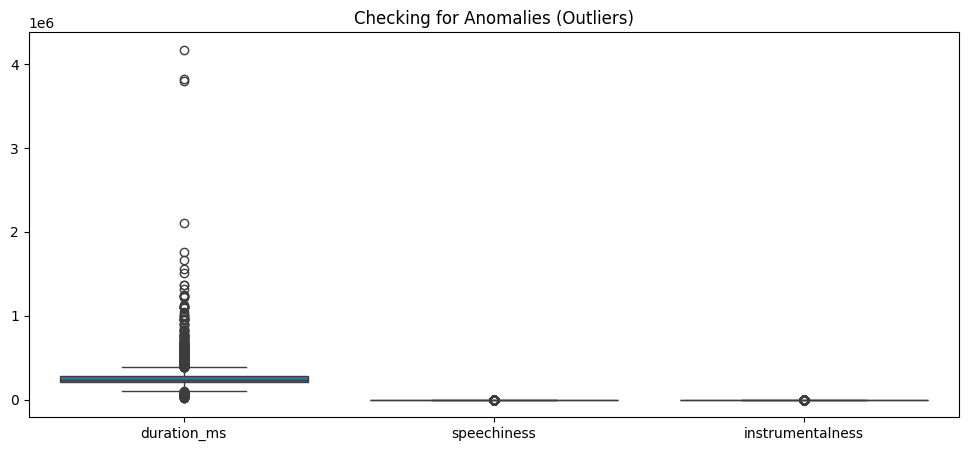

In [8]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=df[['duration_ms', 'speechiness', 'instrumentalness']])
plt.title("Checking for Anomalies (Outliers)")
plt.show()

In [9]:
# Calculate IQR for Duration
Q1 = df['duration_ms'].quantile(0.25)
Q3 = df['duration_ms'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Count how many rows are outside these bounds
outliers = df[(df['duration_ms'] < lower_bound) | (df['duration_ms'] > upper_bound)]
print(f"Rough amount of outliers based on Duration: {len(outliers)}")

Rough amount of outliers based on Duration: 475


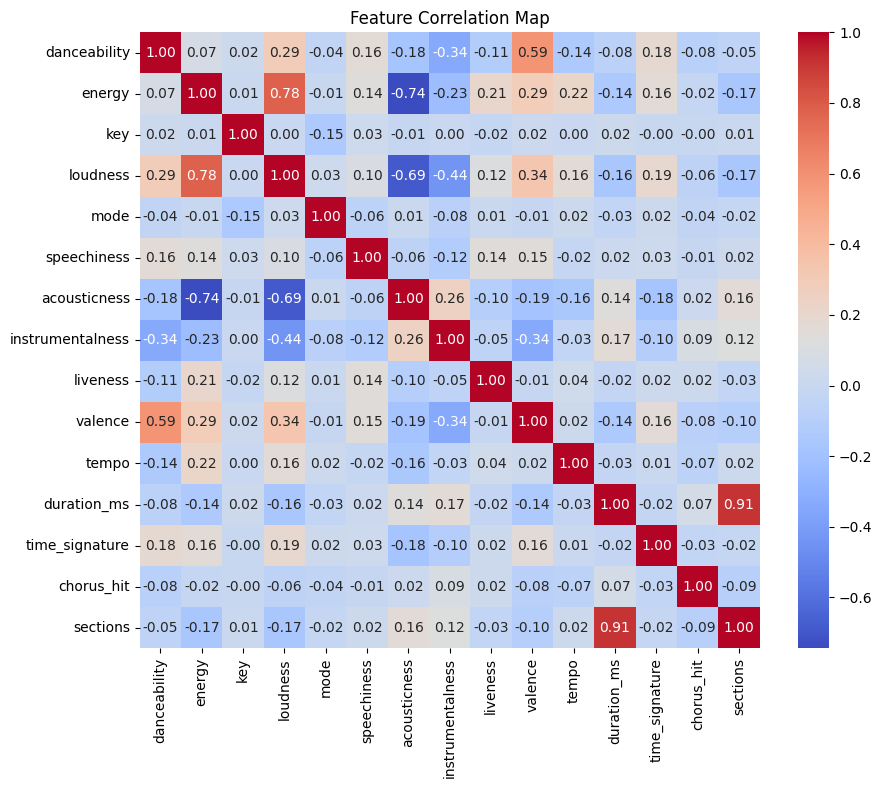

In [10]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[features].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Feature Correlation Map")
plt.show()

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [12]:
pca_check = PCA()
pca_check.fit(X_scaled)
cumsum = np.cumsum(pca_check.explained_variance_ratio_)

In [13]:
cumsum

array([0.22056163, 0.33977091, 0.44649757, 0.52605097, 0.59915637,
       0.6681099 , 0.7295809 , 0.78712305, 0.84321282, 0.894184  ,
       0.93949746, 0.9671011 , 0.98575918, 0.9953478 , 1.        ])

In [14]:
n_components_95 = np.argmax(cumsum >= 0.95) + 1

In [15]:
n_components_95

12

In [16]:
pca_final = PCA(n_components=n_components_95)
X_pca = pca_final.fit_transform(X_scaled)

In [17]:
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)
df['pca1'] = X_2d[:, 0]
df['pca2'] = X_2d[:, 1]

print(f"95% Variance captured using {n_components_95} components.")

95% Variance captured using 12 components.


In [18]:
iso_forest = IsolationForest(contamination=0.05, random_state=42)

In [19]:
df['is_anomaly'] = iso_forest.fit_predict(X_scaled)

anomaly_count = len(df[df['is_anomaly'] == -1])
print(f"Detected {anomaly_count} anomalies in the dataset.")

Detected 293 anomalies in the dataset.


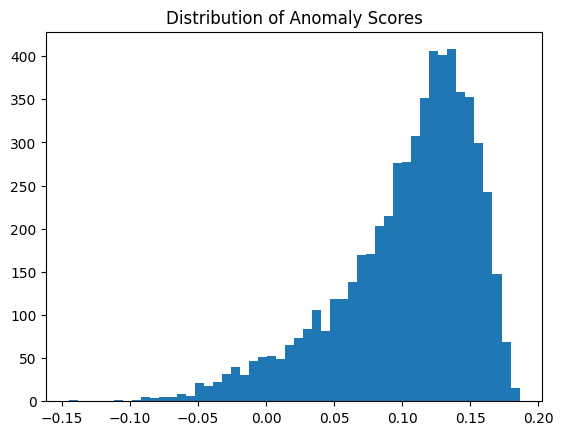

In [20]:
scores = iso_forest.decision_function(X_scaled)

# Plot a histogram of scores
plt.hist(scores, bins=50)
plt.title("Distribution of Anomaly Scores")
plt.show()

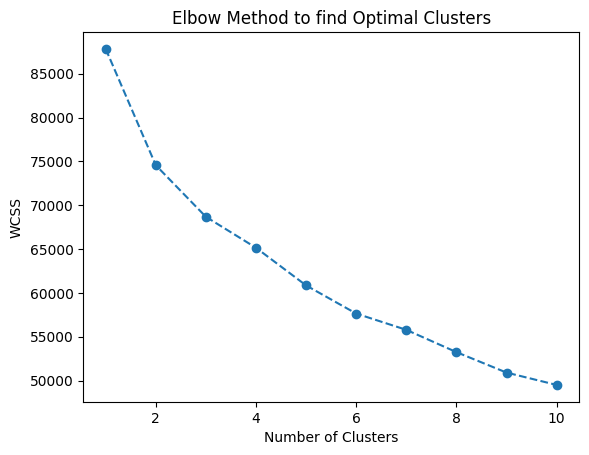

In [21]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plotting the Elbow
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method to find Optimal Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [22]:
normal_songs = df[df['is_anomaly'] == 1]
X_normal = X_scaled[df['is_anomaly'] == 1]

In [23]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df.loc[df['is_anomaly'] == 1, 'cluster_id'] = kmeans.fit_predict(X_normal)

In [24]:
df.loc[df['is_anomaly'] == -1, 'cluster_id'] = 4

In [25]:
print("Final Cluster Counts:")
print(df['cluster_id'].value_counts().sort_index())

Final Cluster Counts:
cluster_id
0.0    1356
1.0    2095
2.0    1439
3.0     672
4.0     293
Name: count, dtype: int64


In [26]:
# Select key features to define the "Civilization"
radar_features = ['danceability', 'energy', 'speechiness', 'acousticness', 'instrumentalness', 'valence']

# Group by cluster and calculate the mean for each feature
civilizations = df.groupby('cluster_id')[radar_features].mean()

print("--- The 5 Cluster Civilizations DNA ---")
print(civilizations)

--- The 5 Cluster Civilizations DNA ---
            danceability    energy  speechiness  acousticness  \
cluster_id                                                      
0.0             0.659799  0.743069     0.110915      0.131483   
1.0             0.647573  0.730150     0.092877      0.146586   
2.0             0.373400  0.853407     0.089685      0.042361   
3.0             0.447443  0.330940     0.050745      0.709733   
4.0             0.302322  0.272086     0.111116      0.791789   

            instrumentalness   valence  
cluster_id                              
0.0                 0.076950  0.609263  
1.0                 0.030107  0.609705  
2.0                 0.222855  0.322204  
3.0                 0.343916  0.292073  
4.0                 0.569691  0.203354  


In [27]:
df.groupby('cluster_id')['duration_ms'].mean()

cluster_id
0.0    250498.027286
1.0    238361.085442
2.0    251541.958304
3.0    269130.316964
4.0    444367.597270
Name: duration_ms, dtype: float64

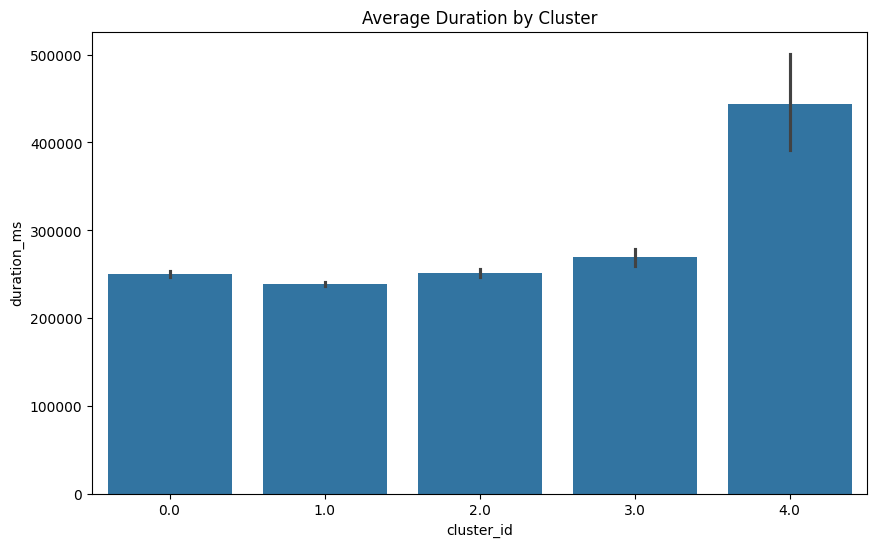

In [28]:
plt.figure(figsize=(10, 6))
sns.barplot(x='cluster_id', y='duration_ms', data=df)
plt.title("Average Duration by Cluster")        
plt.show()

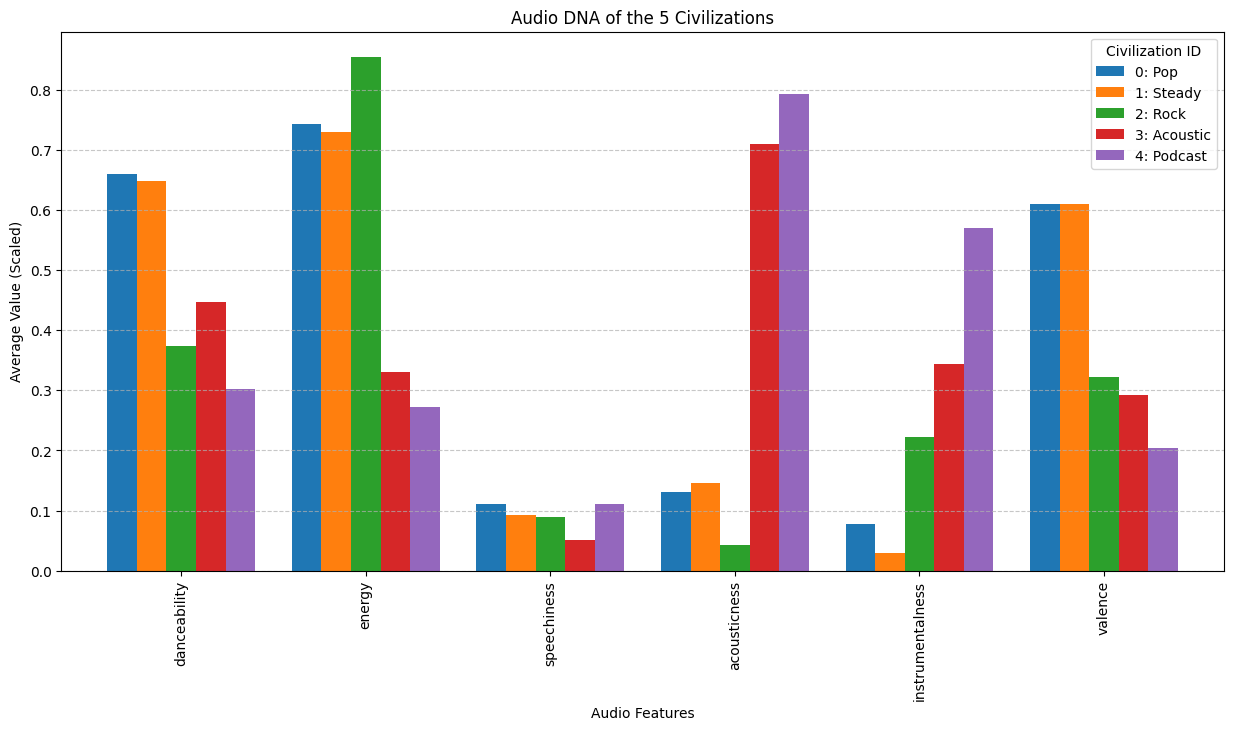

In [29]:
import matplotlib.pyplot as plt

# Plotting the feature breakdown for each civilization
civilizations.T.plot(kind='bar', figsize=(15, 7), width=0.8)
plt.title("Audio DNA of the 5 Civilizations")
plt.ylabel("Average Value (Scaled)")
plt.xlabel("Audio Features")
plt.legend(title="Civilization ID", labels=[
    "0: Pop", "1: Steady", "2: Rock", "3: Acoustic", "4: Podcast"
])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [30]:
import plotly.express as px

# We use the 'cluster_id' or 'cluster_name' column we created earlier
fig = px.pie(
    df, 
    names='cluster_id', # Or 'cluster_name' if you've mapped them
    title='Population of the 5 Civilizations',
    hole=0.4, # This makes it a Donut chart (cleaner look)
    color_discrete_sequence=px.colors.qualitative.Prism
)

fig.update_traces(textinfo='percent+label')
fig.update_layout(template="plotly_dark") # Keeping that Spotify vibe
fig.show()

In [31]:
df.columns

Index(['track', 'artist', 'uri', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'duration_ms', 'time_signature', 'chorus_hit',
       'sections', 'hit_or_miss', 'pca1', 'pca2', 'is_anomaly', 'cluster_id'],
      dtype='object')

In [32]:
# 1. Map the Cluster IDs to the final names we discussed
# (Double check that your cluster_id mapping matches your energy analysis)
mapping = {
    0.0: "Pop / Dance",
    1.0: "Steady / Balanced", 
    2.0: "Rock / Intense",
    3.0: "Acoustic / Chill",
    4.0: "Podcasts / Experimental"
}

df['cluster_name'] = df['cluster_id'].map(mapping)

# 2. Select only the necessary columns to keep the file small and fast for the UI
columns_to_save = [
    'track', 'artist', 'uri', 'danceability', 'energy', 'key', 'loudness', 'mode',
    'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 
    'duration_ms', 'time_signature', 'chorus_hit', 'sections','cluster_id', 
    'cluster_name', 'pca1', 'pca2', 'hit_or_miss'
]

# 3. Save to CSV
df[columns_to_save].to_csv('spotify_final_ml.csv', index=False)

print("✅ Success! 'spotify_final_ml.csv' has been saved.")
print(f"Total tracks saved: {len(df)}")

✅ Success! 'spotify_final_ml.csv' has been saved.
Total tracks saved: 5855


prediction system

In [33]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data splitting and preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Bagging & Boosting
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier

# XGBoost
from xgboost import XGBClassifier

# Evaluation Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Pipeline and Model Saving
from sklearn.pipeline import Pipeline
import joblib

In [34]:
df = pd.read_csv("spotify_final_ml.csv")

df.head()

,track,artist,uri,danceability,energy,key,loudness,mode,speechiness,acousticness,...,tempo,duration_ms,time_signature,chorus_hit,sections,cluster_id,cluster_name,pca1,pca2,hit_or_miss
0,Lucky Man,Montgomery Gentry,spotify:track:4GiXBCUF7H6YfNQsnBRIzl,0.578,0.471,4,-7.270,1,0.0289,0.368000,...,133.061,196707,4,30.88059,13,1.0,Steady / Balanced,-0.308200,-0.224332,1
1,On The Hotline,Pretty Ricky,spotify:track:1zyqZONW985Cs4osz9wlsu,0.704,0.854,10,-5.477,0,0.1830,0.018500,...,92.988,242587,4,41.51106,10,0.0,Pop / Dance,1.447683,0.483081,1
2,Clouds Of Dementia,Candlemass,spotify:track:6cHZf7RbxXCKwEkgAZT4mY,0.162,0.836,9,-3.009,1,0.0473,0.000111,...,86.964,338893,4,65.32887,13,2.0,Rock / Intense,-0.014471,0.306436,0
3,"Heavy Metal, Raise Hell!",Zwartketterij,spotify:track:2IjBPp2vMeX7LggzRN3iSX,0.188,0.994,4,-3.745,1,0.1660,0.000007,...,148.440,255667,4,58.59528,9,2.0,Rock / Intense,0.855204,-0.188628,0
4,I Got A Feelin',Billy Currington,spotify:track:1tF370eYXUcWwkIvaq3IGz,0.630,0.764,2,-4.353,1,0.0275,0.363000,...,112.098,193760,4,22.62384,10,1.0,Steady / Balanced,0.742271,-0.329696,1


In [35]:
df.shape

(5855, 23)

In [36]:
df.columns


Index(['track', 'artist', 'uri', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'duration_ms', 'time_signature', 'chorus_hit',
       'sections', 'cluster_id', 'cluster_name', 'pca1', 'pca2',
       'hit_or_miss'],
      dtype='object')

In [37]:
df["cluster_name"].value_counts()

cluster_name
Steady / Balanced          2095
Rock / Intense             1439
Pop / Dance                1356
Acoustic / Chill            672
Podcasts / Experimental     293
Name: count, dtype: int64

In [38]:
# columns to remove
drop_cols = ["track", "artist", "uri", "cluster_name", "pca1", "pca2", "hit_or_miss", "cluster_id"]
# features
X = df.drop(columns=drop_cols, errors="ignore")

# target
y = df["cluster_id"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (5855, 15)
Target shape: (5855,)


In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (4684, 15)
Test shape: (1171, 15)


In [40]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [41]:
models = {

    "Logistic Regression": LogisticRegression(max_iter=1000),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "SVM": SVC(),

    "KNN": KNeighborsClassifier(n_neighbors=5),

    "Naive Bayes": GaussianNB(),

    "Bagging": BaggingClassifier(
        estimator=SVC(kernel="rbf"),
        n_estimators=100,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(),

    "AdaBoost": AdaBoostClassifier(),

    "XGBoost": XGBClassifier(
        use_label_encoder=False,
        eval_metric="mlogloss"
    )
}

In [42]:
results = {}

for name, model in models.items():

    # train model
    model.fit(X_train_scaled, y_train)

    # predictions
    preds = model.predict(X_test_scaled)

    # metrics
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average="macro")
    rec = recall_score(y_test, preds, average="macro")
    f1 = f1_score(y_test, preds, average="macro")

    # store results
    results[name] = {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1
    }

    print(f"{name} trained successfully")

Logistic Regression trained successfully
Random Forest trained successfully
SVM trained successfully
KNN trained successfully
Naive Bayes trained successfully
Bagging trained successfully
Gradient Boosting trained successfully
AdaBoost trained successfully


c:\Users\lokes\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:17:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost trained successfully


In [43]:
results_df = pd.DataFrame(results).T

# sort by best metric (F1 Score for multiclass)
results_df = results_df.sort_values(by="F1 Score", ascending=False)

results_df

,Accuracy,Precision,Recall,F1 Score
Bagging,0.964133,0.942275,0.930602,0.936159
SVM,0.962425,0.940741,0.927706,0.933804
Logistic Regression,0.961571,0.928789,0.918668,0.922996
XGBoost,0.947908,0.927031,0.906956,0.916052
Gradient Boosting,0.944492,0.923336,0.909643,0.915756
Random Forest,0.930828,0.916150,0.876534,0.891198
KNN,0.909479,0.899273,0.831309,0.853768
AdaBoost,0.777968,0.798508,0.719806,0.732468
Naive Bayes,0.766866,0.803475,0.721674,0.721814


In [44]:
best_model_name = results_df["F1 Score"].idxmax()

print("Best Model:", best_model_name)
print("Best F1 Score:", results_df.loc[best_model_name, "F1 Score"])

Best Model: Bagging
Best F1 Score: 0.9361585640338357


In [45]:
best_model = models[best_model_name]

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", best_model)
])

pipeline.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",SVC()
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",100
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",None
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0


In [46]:
joblib.dump(pipeline, "cluster_prediction_pipeline.pkl")

print("Model saved successfully")

Model saved successfully


hit prediction

In [47]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [48]:
drop_cols = [
    "track",
    "artist",
    "uri",
    "cluster_name",
    "cluster_id",
    "pca1",
    "pca2"
    "hit_or_miss"
]

X_hit = df.drop(columns=drop_cols, errors="ignore")

y_hit = df["hit_or_miss"]

print(X_hit.shape)
print(y_hit.shape)

(5855, 17)
(5855,)


In [49]:
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_hit,
    y_hit,
    test_size=0.2,
    random_state=42,
    stratify=y_hit
)

In [50]:
scaler_hit = StandardScaler()

X_train_h = scaler_hit.fit_transform(X_train_h)
X_test_h = scaler_hit.transform(X_test_h)

In [51]:
model = Sequential()

model.add(Dense(64, activation="relu", input_shape=(X_train_h.shape[1],)))
model.add(Dropout(0.3))

model.add(Dense(32, activation="relu"))
model.add(Dropout(0.2))

model.add(Dense(16, activation="relu"))

model.add(Dense(1, activation="sigmoid"))

In [52]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [53]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_h,
    y_train_h,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/200


118/118 [==============================] - 1s 3ms/step - loss: 0.2982 - accuracy: 0.8940 - val_loss: 0.0222 - val_accuracy: 1.0000
Epoch 2/200
118/118 [==============================] - 0s 1ms/step - loss: 0.0315 - accuracy: 0.9949 - val_loss: 0.0020 - val_accuracy: 1.0000
Epoch 3/200
118/118 [==============================] - 0s 1ms/step - loss: 0.0100 - accuracy: 0.9979 - val_loss: 4.5822e-04 - val_accuracy: 1.0000
Epoch 4/200
118/118 [==============================] - 0s 1ms/step - loss: 0.0051 - accuracy: 0.9984 - val_loss: 1.6768e-04 - val_accuracy: 1.0000
Epoch 5/200
118/118 [==============================] - 0s 1ms/step - loss: 0.0031 - accuracy: 0.9992 - val_loss: 7.2461e-05 - val_accuracy: 1.0000
Epoch 6/200
118/118 [==============================] - 0s 1ms/step - loss: 0.0023 - accuracy: 0.9995 - val_loss: 3.4685e-05 - val_accuracy: 1.0000
Epoch 7/200
118/118 [==============================] - 0s 1ms/step - loss: 0.0058 - accuracy: 0.9997 - val_loss: 3.6076e-05 

In [54]:
loss, accuracy = model.evaluate(X_test_h, y_test_h)

print("Test Accuracy:", accuracy)

37/37 [==============================] - 0s 805us/step - loss: 3.9376e-12 - accuracy: 1.0000
Test Accuracy: 1.0


In [55]:
model.save("hit_prediction_ann_model.h5")

joblib.dump(scaler_hit, "hit_scaler.pkl")

c:\Users\lokes\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


['hit_scaler.pkl']